#PROBLEM 1: LEARNING WORD EMBEDDINGS FROM IIT JODHPUR DATA

In [1]:
!pip install pdfplumber gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 77.7 MB/s eta 0:00:00


In [2]:
import pdfplumber
import itertools
import requests
from bs4 import BeautifulSoup
import re
import os
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from io import BytesIO
import numpy as np
import pandas as pd
import random

In [4]:
import torch
import torch.nn as nn
import string
import time

random.seed(42)

In [3]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

##TASK-1: DATASET PREPARATION

In [5]:
# Obtain the URLs to scrape
urls = [
    "https://iitj.ac.in/m/Index/main-departments",
    "https://iitj.ac.in/computer-science-engineering/",         #cse
    "https://iitj.ac.in/computer-science-engineering/en/undergraduate-programs",
    "https://iitj.ac.in/computer-science-engineering/en/postgraduate-programs",
    "https://iitj.ac.in/computer-science-engineering/en/doctoral-programs",
    "https://iitj.irins.org/faculty/index/Department+of+Computer+Science+and+Engineering",
    "https://iitj.ac.in/People/Profile/c7aa696c-0f3d-48aa-ad32-eeb189bdca60",
    "https://home.iitj.ac.in/~mvatsa/",
    "https://iitj.ac.in/People/Profile/9d7c7c5b-4ddf-487e-a00c-ab2c5878b9a4",
    "https://home.iitj.ac.in/~richa/",
    "https://3dcomputervision.github.io/",
    "https://iitj.ac.in/People/Profile/214803fd-cce9-456f-ae72-ef3f65eb700e",
    "https://sites.google.com/view/debasisdas/home",
    "https://sites.google.com/iitj.ac.in/dmishra",
    "https://iitj.ac.in/People/Profile/52db0e41-e9cb-48da-a073-82fdb8e34c8e",
    "https://sites.google.com/site/dipsankarban/home",
    "https://home.iitj.ac.in/~pallavi/",
    "https://sites.google.com/site/suchetana0116",
    "https://home.iitj.ac.in/~sumitk/",
    "https://sites.google.com/view/yashaswiverma/",
    "https://iitj.ac.in/People/Profile/e9793af3-6d4f-4560-8489-2c256912a72a",
    "https://anandmishra22.github.io/",
    "https://sites.google.com/view/angshumanpaul/",
    "https://medisalab.github.io/MedISA/",
    "https://home.iitj.ac.in/~hardikjain/",
    "https://mohitwrangler.github.io/",
    "https://nitinawathare.github.io/",
    "https://home.iitj.ac.in/~palashdas/",
    "https://sites.google.com/view/pratikmazumder/",
    "https://sites.google.com/site/romibitsnbob/home",
    "https://home.iitj.ac.in/~sidharth/",
    "https://sites.google.com/iitj.ac.in/susil/",
    "https://home.iitj.ac.in/~vimalraj/",
    "https://home.iitj.ac.in/~bikash/",
    "https://divvyasaxena.github.io/Divya-Saxena/",
    "https://sites.google.com/view/srivatsasrinivas/home",
    "https://iitj.ac.in/computer-science-engineering/en/Annoncement-Archive",
    "https://iitj.ac.in/materials-engineering/",        #mme
    "https://iitj.ac.in/materials-engineering/en/undergraduate-program",
    "https://iitj.ac.in/materials-engineering/en/doctoral-programs",
    "https://iitj.irins.org/faculty/index/Department+of+Materials+Engineering",
    "https://iitj.ac.in/materials-engineering/en/News-Newsletter",
    "https://iitj.ac.in/mechanical-engineering/",    #mech
    "https://iitj.ac.in/mechanical-engineering/en/undergraduate-program",
    "https://iitj.ac.in/mechanical-engineering/en/postgraduate-program",
    "https://iitj.ac.in/mechanical-engineering/en/doctorial-program",
    "https://iitj.irins.org/faculty/index/Department+of+Mechanical+Engineering",
    "https://iitj.ac.in/mechanical-engineering/en/News-Newsletter",
    "https://iitj.ac.in/mathematics/",          #maths
    "https://iitj.ac.in/mathematics/en/undergraduate-programs",
    "https://iitj.ac.in/mathematics/en/postgraduate-programs",
    "https://iitj.ac.in/mathematics/en/doctoral-program",
    "https://iitj.irins.org/faculty/index/Department+of+Mathematics",
    "https://home.iitj.ac.in/~goravb/",
    "https://sites.google.com/view/sharmapuneet/home",
    "https://sites.google.com/iitj.ac.in/dr-tuhina-mukherjee/home",
    "https://iitj.ac.in/mathematics/en/Announcement-Page",
    "https://iitj.ac.in/electrical-engineering/",         #ee
    "https://iitj.ac.in/electrical-engineering/en/undergraduate-program",
    "https://iitj.ac.in/electrical-engineering/en/postgraduate-program",
    "https://iitj.ac.in/electrical-engineering/en/doctoral-program",
    "https://iitj.irins.org/faculty/index/Department+of+Electrical+Engineering",
    "https://sites.google.com/iitj.ac.in/rims/rims-head",
    "https://bharatsrajpurohit.weebly.com/",
    "https://sites.google.com/a/iitj.ac.in/deepak-fulwani/home",
    "https://sites.google.com/iitj.ac.in/mkumar/home",
    "https://home.iitj.ac.in/~sy/",
    "https://home.iitj.ac.in/~sptiwari/",
    "https://mathur329.wixsite.com/aashishmathur",
    "https://home.iitj.ac.in/~amitb/index.html",
    "https://home.iitj.ac.in/~agarwalh/",
    "https://home.iitj.ac.in/~jai/",
    "https://home.iitj.ac.in/~nishantkumar/",
    "https://sites.google.com/view/kunwar-aditya/",
    "https://home.iitj.ac.in/~nitin/",
    "https://sites.google.com/iitj.ac.in/rajlaxmichouhan",
    "https://saakshi40.wixsite.com/mysite",
    "https://sites.google.com/site/soumavamukherjeebesus/home",
    "https://www.aem-group.org/",
    "https://sites.google.com/view/akshaymoudgil/home",
    "https://sites.google.com/iitj.ac.in/amandeepkaur",
    "https://sites.google.com/view/anoopjain",
    "https://gsbhupendra.wixsite.com/bhupendrar",
    "https://binodkumar23.github.io/",
    "https://home.iitj.ac.in/~manojgupta/",
    "https://sites.google.com/view/vramachandran/home",
    "https://sites.google.com/iitj.ac.in/profsurajsrivastava/home",
    "https://sites.google.com/view/sauravkr/home",
    "https://sites.google.com/iitj.ac.in/raviyadav/home",
    "https://home.iitj.ac.in/~rn/",
    "https://sites.google.com/site/resumepradyumna/home"
    "https://iitj.ac.in/Electrical-Engineering/en/News-Newsletter",
    "https://iitj.ac.in/civil-and-infrastructure-engineering/",      #civil
    "https://iitj.ac.in/civil-and-infrastructure-engineering/en/btech",
    "https://iitj.ac.in/civil-and-infrastructure-engineering/en/mtech-in-energy-infrastructure",
    "https://iitj.ac.in/civil-and-infrastructure-engineering/en/mtech-in-environmental-engineering",
    "https://iitj.ac.in/civil-and-infrastructure-engineering/en/phd-programs",
    "https://iitj.irins.org/faculty/index/Department+of+Civil+and+Infrastructure+Engineering",
    "https://iitj.ac.in/civil-and-infrastructure-engineering/en/News-and-Newsletter"
    "https://iitj.ac.in/chemical-engineering/",         #chemical
    "https://iitj.ac.in/chemical-engineering/en/undergraduate-program",
    "https://iitj.ac.in/chemical-engineering/en/postgraduate-program",
    "https://iitj.ac.in/chemical-engineering/en/doctoral-program",
    "https://iitj.irins.org/faculty/index/Department+of+Chemical+Engineering",
    "https://iitj.ac.in/chemical-engineering/en/Latest-News",
    "https://iitj.ac.in/chemistry/",        #chem
    "https://old.iitj.ac.in/uploaded_docs/dept_upload/chem/BS%20curriculam_document-2025-03-21-15-18-pm.pdf",
    "https://iitj.ac.in/bioscience-bioengineering",        #bsbe
    "https://iitj.ac.in/bioscience-bioengineering/en/undergraduate-program",
    "https://iitj.ac.in/bioscience-bioengineering/en/postgraduate-program",
    "https://iitj.ac.in/bioscience-bioengineering/en/doctorial-program",
    "https://iitj.irins.org/faculty/index/Department+of+Bioscience+and+Bioengineering",
    "https://envbiotechiitj.wixsite.com/mysite",
    "https://iitj.ac.in/People/Profile/0a35133e-df53-421a-86ef-1ef9a327fbe2",
    "https://home.iitj.ac.in/~sghosh/index.php",
    "https://iitj.ac.in/People/Profile/430f7be3-95d2-4f60-9547-8488def6c02a",
    "https://iitj.ac.in/People/Profile/d22ce5ab-e4b8-41e2-8ad1-224d0199e231",
    "https://www.tissueengineering-iitj.com/",
    "https://iitj.ac.in/People/Profile/1cf4dea1-95f5-4df3-98c8-58dafdc29fbb",
    "https://jain-lab.wixsite.com/jainlab",
    "https://iitj.ac.in/People/Profile/8da833ca-ddf0-4573-a255-2ec5ff1cad0e",
    "https://iitj.ac.in/People/Profile/3c808055-5a08-4ab4-93b4-d4b93907a615",
    "https://iitj.ac.in/People/Profile/6efb8e3a-4a9a-462e-a672-176a5b7ebbca",
    "https://iitj.ac.in/People/Profile/db26b245-e616-4195-ba92-29252e3f66dc",
    "https://iitj.ac.in/People/Profile/ba433f28-e067-48f5-b1c3-e0ccbda9eff6",
    "https://iitj.ac.in/People/Profile/85cc96f5-12a4-4b76-9c2a-35d7180f912b",
    "https://iitj.ac.in/People/Profile/97b9be38-8cf7-42b0-becc-03c8be076400",
    "https://iitj.ac.in/People/Profile/ab8b7203-7570-42d4-bf27-90e07b057c4d",
    "https://iitj.ac.in/People/Profile/dcba7c86-0698-466e-b17a-9504b80c2dd7",
    "https://sites.google.com/view/sdey-iitj/home",
    "https://iitj.ac.in/bioscience-bioengineering/en/Announcement",
    "https://iitj.ac.in/physics/",                #physics
    "https://iitj.ac.in/physics/en/undergraduate-program",
    "https://iitj.ac.in/physics/en/postgraduate-program",
    "https://iitj.ac.in/physics/en/doctoral-program",
    "https://iitj.irins.org/faculty/index/Department+of+Physics",
    "https://iitj.ac.in/physics/en/Latest-News",
    "https://iitj.irins.org/"
]

In [6]:
# Scrape function
def scrape_text(url):
    try:
        response = requests.get(url, timeout=10)

        if url.endswith(".pdf"):
            return extract_pdf_from_url(response.content)

        soup = BeautifulSoup(response.text, "html.parser")
        text = " ".join([tag.get_text() for tag in soup.find_all(["p", "li"])])
        return text
    except:
        return ""

# Function to scrape from pdf (if in url)
def extract_pdf_from_url(pdf_bytes):
    text = ""
    try:
        with pdfplumber.open(BytesIO(pdf_bytes)) as pdf:
            for page in pdf.pages:
                text += page.extract_text() or ""
    except:
        print("Error reading PDF from URL")
    return text


# Local folder containing circular, regulations and other documents
PDF_FOLDER = "/content/circulars/"

# Extract from documents in local folder
def extract_pdf_local(path):
    text = ""
    try:
        with pdfplumber.open(path) as pdf:
            for page in pdf.pages:
                text += page.extract_text() or ""
    except:
        print(f"Error reading {path}")
    return text

In [7]:
# Preprocessing
stop_words = set(stopwords.words('english'))

def preprocess(text):
    # (i) remove HTML tags/boilerplate
    text = re.sub(r'<.*?>', ' ', text)

    # (iv) remove non-english chars
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)

    # (iii) convert to lowercase
    text = text.lower()

    # (i) remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # (iv) keep only alphabets
    text = re.sub(r'[^a-z\s]', ' ', text)

    # (iv) remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    # (ii) tokenization
    tokens = word_tokenize(text)

    # (iv) remove punctuation
    tokens = [word for word in tokens if word not in string.punctuation]

    # (iv) remove stopwords
    tokens = [w for w in tokens if w not in stop_words]

    return tokens


# Creation of clean corpus
documents = []
all_tokens = []

## Scrape URLs
for url in urls:
    print("Processing URL:", url)
    raw_text = scrape_text(url)
    tokens = preprocess(raw_text)

    if len(tokens) > 50:
        documents.append(tokens)
        all_tokens.extend(tokens)

## Process local documents
if os.path.exists(PDF_FOLDER):
    for file in os.listdir(PDF_FOLDER):
        if file.endswith(".pdf"):
            path = os.path.join(PDF_FOLDER, file)
            print("Processing PDF:", file)

            raw_text = extract_pdf_local(path)
            tokens = preprocess(raw_text)

            if len(tokens) > 100:
                documents.append(tokens)
                all_tokens.extend(tokens)

Processing URL: https://iitj.ac.in/m/Index/main-departments
Processing URL: https://iitj.ac.in/computer-science-engineering/
Processing URL: https://iitj.ac.in/computer-science-engineering/en/undergraduate-programs
Processing URL: https://iitj.ac.in/computer-science-engineering/en/postgraduate-programs
Processing URL: https://iitj.ac.in/computer-science-engineering/en/doctoral-programs
Processing URL: https://iitj.irins.org/faculty/index/Department+of+Computer+Science+and+Engineering
Processing URL: https://iitj.ac.in/People/Profile/c7aa696c-0f3d-48aa-ad32-eeb189bdca60
Processing URL: https://home.iitj.ac.in/~mvatsa/
Processing URL: https://iitj.ac.in/People/Profile/9d7c7c5b-4ddf-487e-a00c-ab2c5878b9a4
Processing URL: https://home.iitj.ac.in/~richa/
Processing URL: https://3dcomputervision.github.io/
Processing URL: https://iitj.ac.in/People/Profile/214803fd-cce9-456f-ae72-ef3f65eb700e
Processing URL: https://sites.google.com/view/debasisdas/home
Processing URL: https://sites.google.co

In [8]:
# Dataset Statistics
total_docs = len(documents)
total_tokens = len(all_tokens)
vocab = set(all_tokens)
vocab_size = len(vocab)

print("DATASET STATS:-")
print("Total Documents:", total_docs)
print("Total Tokens:", total_tokens)
print("Vocabulary Size:", vocab_size)

# Additionally save the corpus (in dataset folder)
os.makedirs("dataset", exist_ok=True)

with open("dataset/corpus.txt", "w", encoding="utf-8") as f:
    for doc in documents:
        f.write(" ".join(doc) + "\n")

DATASET STATS:-
Total Documents: 125
Total Tokens: 53120
Vocabulary Size: 6021


In [9]:
# Print top 10 words
word_freq = Counter(all_tokens)

print("Top 10 most frequent words in the corpus:-")
for word, freq in word_freq.most_common(10):
    print(f"{word}: {freq}")

Top 10 most frequent words in the corpus:
research: 771
program: 584
engineering: 540
jodhpur: 438
iit: 401
students: 344
members: 328
department: 325
projects: 324
systems: 313


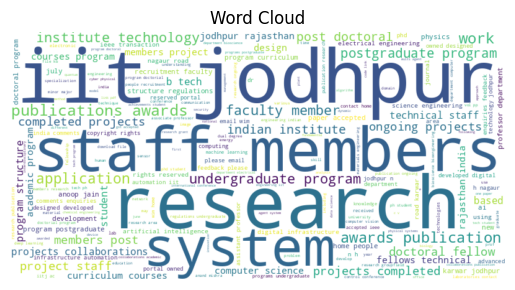

In [ ]:
# Illustration of the word cloud
text = " ".join(all_tokens)

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud")
plt.show()

## TASK-2: MODEL TRAINING

In [10]:
# Load corpus
sentences = []

with open("dataset/corpus.txt", "r", encoding="utf-8") as f:
    for line in f:
        tokens = line.strip().split()
        if len(tokens) > 2:
            sentences.append(tokens)

print("Total sentences:", len(sentences))

Total sentences: 125


In [11]:
# Build vocabulary
words = [word for s in sentences for word in s]
vocab = list(set(words))

word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

vocab_size = len(vocab)

In [13]:
# Data generation functions
## For CBOW
def generate_cbow_data(sentences, window_size):
    data = []

    for s in sentences:
        for i, target in enumerate(s):
            context = []

            for j in range(-window_size, window_size + 1):
                if j != 0 and 0 <= i + j < len(s):
                    context.append(word2idx[s[i + j]])
            target_idx = word2idx[target]
            data.append((context, target_idx))
    return data

## For Skip-gram
def generate_skipgram_data(sentences, window_size):
    data = []

    for s in sentences:
        for i, target in enumerate(s):
            for j in range(-window_size, window_size + 1):
                if j != 0 and 0 <= i + j < len(s):
                    context_idx = word2idx[s[i + j]]
                    data.append((word2idx[target], context_idx))
    return data

In [14]:
# Continuous Bag of Words (CBOW) Model
class CBOW:
    def __init__(self, vocab_size, embedding_dim):
        # self.vocab_size = vocab_size
        # self.embedding_dim = embedding_dim
        self.W1 = np.random.randn(vocab_size, embedding_dim)
        self.W2 = np.random.randn(embedding_dim, vocab_size)

    def forward(self, context_indices):
        h = np.mean(self.W1[context_indices], axis=0)
        u = np.dot(h, self.W2)
        y_pred = self.softmax(u)
        return y_pred, h

    def softmax(self, x):
        e_x = np.exp(x - np.max(x))
        return e_x / e_x.sum()

    def train(self, data, epochs=5, lr=0.01):
        for epoch in range(epochs):
            loss = 0
            for context, target in data:
                y_pred, h = self.forward(context)

                loss -= np.log(y_pred[target] + 1e-9)

                # Backprop
                e = y_pred
                e[target] -= 1

                self.W2 -= lr * np.outer(h, e)
                for idx in context:
                    self.W1[idx] -= lr * np.dot(self.W2, e) / len(context)

            avg_loss = loss / len(data)
            print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

        return avg_loss

In [15]:
# Skip-gram with Negative Sampling
class SkipGramNS:
    def __init__(self, vocab_size, embedding_dim, neg_samples=5):
        # self.vocab_size = vocab_size
        # self.embedding_dim = embedding_dim
        self.neg_samples = neg_samples
        self.W1 = np.random.randn(vocab_size, embedding_dim)
        self.W2 = np.random.randn(vocab_size, embedding_dim)

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def train(self, data, epochs=5, lr=0.01):
        for epoch in range(epochs):
            loss = 0

            for target, context in data:
                target_vec = self.W1[target]

                # Positive sample
                score = self.sigmoid(np.dot(self.W2[context], target_vec))
                loss -= np.log(score + 1e-9)

                grad = lr * (score - 1)
                self.W2[context] -= grad * target_vec
                self.W1[target] -= grad * self.W2[context]

                # Negative samples
                for _ in range(self.neg_samples):
                    neg_word = random.randint(0, vocab_size - 1)

                    score = self.sigmoid(np.dot(self.W2[neg_word], target_vec))
                    loss -= np.log(1 - score + 1e-9)

                    grad = lr * score
                    self.W2[neg_word] -= grad * target_vec
                    self.W1[target] -= grad * self.W2[neg_word]

            avg_loss = loss / len(data)
            print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

        return avg_loss

In [17]:
# Hyperparameters
embedding_dims = [50, 100]
win_sizes = [2, 4]
neg_samples_list = [2, 5]

In [18]:
results = []

# Experiments with hyperparameters of CBOW
for emb in embedding_dims:
    for w in win_sizes:
        print(f"\nCBOW: Embedding={emb}, Window={w}")

        cbow_data = generate_cbow_data(sentences, w)

        model = CBOW(vocab_size, emb)

        start_time = time.time()
        final_loss = model.train(cbow_data, epochs=5)
        end_time = time.time()

        training_time = end_time - start_time

        results.append(["CBOW", emb, w, "-", final_loss, training_time])

        print("-----------------------------------------")


CBOW: Embedding=50, Window=2
Epoch 1, Loss: 12.5228
Epoch 2, Loss: 10.3960
Epoch 3, Loss: 9.3426
Epoch 4, Loss: 8.5953
Epoch 5, Loss: 8.0094
-----------------------------------------

CBOW: Embedding=50, Window=4
Epoch 1, Loss: 10.8277
Epoch 2, Loss: 9.4903
Epoch 3, Loss: 8.7680
Epoch 4, Loss: 8.2513
Epoch 5, Loss: 7.8393
-----------------------------------------

CBOW: Embedding=100, Window=2
Epoch 1, Loss: 15.2291
Epoch 2, Loss: 12.3521
Epoch 3, Loss: 10.8289
Epoch 4, Loss: 9.6935
Epoch 5, Loss: 8.7802
-----------------------------------------

CBOW: Embedding=100, Window=4
Epoch 1, Loss: 12.8573
Epoch 2, Loss: 10.7989
Epoch 3, Loss: 9.7383
Epoch 4, Loss: 8.9558
Epoch 5, Loss: 8.3260
-----------------------------------------


In [19]:
#Experiments with hyperparameters of Skip-gram with Negative Sampling
for emb in embedding_dims:
    for w in win_sizes:
        for neg in neg_samples_list:
            print(f"\nSGNS: Emb={emb}, Win={w}, Neg={neg}")

            sg_data = generate_skipgram_data(sentences, w)

            model = SkipGramNS(vocab_size, emb, neg)

            start_time = time.time()
            final_loss = model.train(sg_data, epochs=5)
            end_time = time.time()

            results.append(["SkipGram", emb, w, neg, final_loss, end_time-start_time])

            print("-----------------------------------------")


SGNS: Emb=50, Win=2, Neg=2
Epoch 1, Loss: 6.5745
Epoch 2, Loss: 4.7838
Epoch 3, Loss: 4.0114
Epoch 4, Loss: 3.5104
Epoch 5, Loss: 3.0640
-----------------------------------------

SGNS: Emb=50, Win=2, Neg=5
Epoch 1, Loss: 11.9591
Epoch 2, Loss: 7.9942
Epoch 3, Loss: 5.5471
Epoch 4, Loss: 4.1014
Epoch 5, Loss: 3.3580
-----------------------------------------

SGNS: Emb=50, Win=4, Neg=2
Epoch 1, Loss: 5.8254
Epoch 2, Loss: 3.9324
Epoch 3, Loss: 3.0481
Epoch 4, Loss: 2.4018
Epoch 5, Loss: 2.0354
-----------------------------------------

SGNS: Emb=50, Win=4, Neg=5
Epoch 1, Loss: 10.0467
Epoch 2, Loss: 4.8571
Epoch 3, Loss: 3.2645
Epoch 4, Loss: 2.6051
Epoch 5, Loss: 2.2227
-----------------------------------------

SGNS: Emb=100, Win=2, Neg=2
Epoch 1, Loss: 9.1911
Epoch 2, Loss: 6.6965
Epoch 3, Loss: 5.4734
Epoch 4, Loss: 4.6789
Epoch 5, Loss: 3.9662
-----------------------------------------

SGNS: Emb=100, Win=2, Neg=5
Epoch 1, Loss: 17.2166
Epoch 2, Loss: 10.9442
Epoch 3, Loss: 7.2992


In [20]:
# Comparision results
df = pd.DataFrame(results, columns=[
    "Model", "Embedding", "Window", "NegSamples", "Loss", "Time"])

print("\nFinal Results:\n", df)

df.to_csv("results.csv", index=False)


Final Results:
        Model  Embedding  Window NegSamples      Loss         Time
0       CBOW         50       2          -  8.009422   568.335726
1       CBOW         50       4          -  7.839325   656.624172
2       CBOW        100       2          -  8.780241  1382.068668
3       CBOW        100       4          -  8.325982  1764.038742
4   SkipGram         50       2          2  3.064014    36.988131
5   SkipGram         50       2          5  3.357986    74.014153
6   SkipGram         50       4          2  2.035388    73.919620
7   SkipGram         50       4          5  2.222664   149.777179
8   SkipGram        100       2          2  3.966209    36.678795
9   SkipGram        100       2          5  4.333069    76.192916
10  SkipGram        100       4          2  2.549813    75.160929
11  SkipGram        100       4          5  2.677584   152.808557


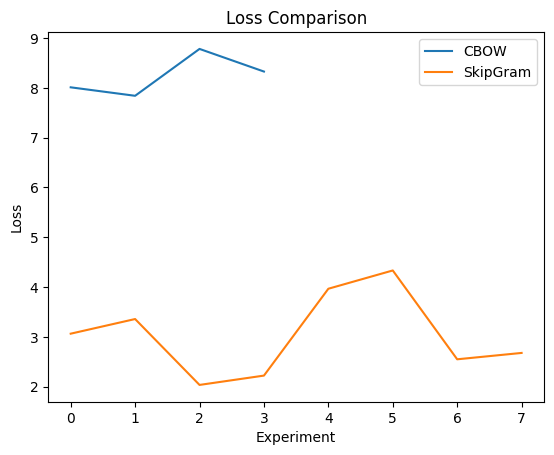

In [21]:
# Plotting the results

plt.figure()
for model in df["Model"].unique():
    subset = df[df["Model"] == model]
    plt.plot(range(len(subset)), subset["Loss"], label=model)

plt.legend()
plt.title("Loss Comparison")
plt.xlabel("Experiment")
plt.ylabel("Loss")
plt.show()

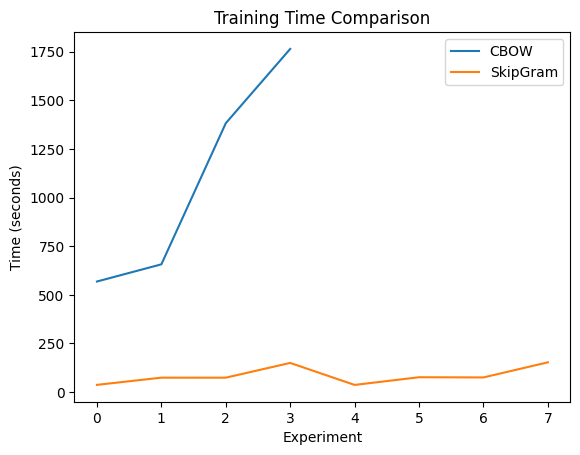

In [22]:
for model_name in df["Model"].unique():
    subset = df[df["Model"] == model_name]

    plt.plot(range(len(subset)), subset["Time"], label=model_name)

plt.xlabel("Experiment")
plt.ylabel("Time (seconds)")
plt.title("Training Time Comparison")
plt.legend()
plt.show()

#### Comparision with exisiting Word2Vec

In [37]:
from gensim.models import Word2Vec

In [38]:
# CBOW
cbow_model2 = Word2Vec(
    sentences,
    vector_size=100,
    window=4,
    sg=0  # CBOW
)

In [39]:
# Skip-gram
sg_model2 = Word2Vec(
    sentences,
    vector_size=100,
    window=4,
    sg=1,         # skipgram
    negative=5
)

In [40]:
# Example similarity
print("CBOW:", cbow_model2.wv.most_similar("student", topn=5))
print("Skip-gram:", sg_model2.wv.most_similar("student", topn=5))

CBOW: [('teams', 0.9858323931694031), ('alumni', 0.9840720295906067), ('placements', 0.9800592064857483), ('phd', 0.9798588752746582), ('chapter', 0.9779984354972839)]
Skip-gram: [('teams', 0.9390504360198975), ('chapter', 0.9284191131591797), ('placements', 0.9209409952163696), ('alumni', 0.8961309790611267), ('outstanding', 0.8948506116867065)]


In [90]:
sg_data3 = generate_skipgram_data(sentences, 4)
model3 = SkipGramNS(vocab_size, 300, 5)
final_loss = model3.train(sg_data3, epochs=10)

Epoch 1, Loss: 22.9599
Epoch 2, Loss: 10.7814
Epoch 3, Loss: 6.8451
Epoch 4, Loss: 4.8447
Epoch 5, Loss: 3.6142
Epoch 6, Loss: 2.8259
Epoch 7, Loss: 2.2630
Epoch 8, Loss: 1.8914
Epoch 9, Loss: 1.5947
Epoch 10, Loss: 1.3850


In [91]:
get_embedding("student", model3)

array([ 1.97253357e-01,  1.69736397e-01, -7.06951650e-02, -6.77134354e-02,
        5.86919887e-02, -1.45119040e-01,  7.45215156e-01,  1.49824153e-01,
        5.29069979e-02, -2.58675247e-01,  3.28235612e-01, -2.22165133e-01,
        4.45022953e-02,  1.45328170e-01,  4.60121759e-01, -1.53594560e-01,
        2.99674054e-02,  6.56793863e-02,  4.61365795e-02,  1.20415031e-01,
       -2.69496371e-01, -3.04988916e-02, -5.45937278e-02,  7.27212628e-02,
        2.49225597e-01,  1.71487621e-02,  1.07213990e-01, -2.82142885e-01,
        7.23155422e-02, -1.83717602e-01, -4.06759135e-01, -3.59061819e-01,
       -6.25119965e-02, -2.19184266e-02, -2.76253849e-01,  3.88389927e-01,
        2.74293409e-01,  6.72684600e-01, -5.73428855e-02,  6.61902207e-02,
       -1.32752710e-01, -2.47692767e-01, -5.92359627e-02,  6.88047718e-02,
       -2.52845041e-01,  3.39044441e-01, -1.30274506e-01,  1.53386955e-01,
       -2.49904470e-01, -2.86051530e-01,  5.47339919e-02,  1.03511972e-01,
       -3.87483400e-02, -

##TASK-3: SEMANTIC ANALYSIS

### Part 1

In [166]:
from numpy.linalg import norm

def get_embedding(word, model):
    if isinstance(model, Word2Vec):
        if word in model.wv.key_to_index:
            return model.wv.get_vector(word)
        else:
            return None
    else:
        if word not in word2idx:
            return None
        return model.W1[word2idx[word]]

def cosine_similarity(vec1, vec2):
    #to prevent division by zero
    norm_vec1 = norm(vec1)
    norm_vec2 = norm(vec2)
    if norm_vec1 == 0 or norm_vec2 == 0:
        return 0.0
    return np.dot(vec1, vec2) / (norm_vec1 * norm_vec2)

def top_neighbors(word, model, top_n=5):
    target_vec = get_embedding(word, model)

    if target_vec is None:
        return f"{word} not in vocabulary"

    similarities = {}

    # determine the vocabulary to iterate based on model type
    vocab_to_iterate = model.wv.key_to_index.keys() if isinstance(model, Word2Vec) else vocab

    for w in vocab_to_iterate:
        if w == word:
            continue
        vec = get_embedding(w, model)
        if vec is not None:
            sim = cosine_similarity(target_vec, vec)
            similarities[w] = sim

    sorted_words = sorted(similarities.items(), key=lambda x: x[1], reverse=True)
    return sorted_words[:top_n]

In [88]:
# With trained skip gram (scratch)
words_to_test = ["research", "student", "phd", "exam"]

for w in words_to_test:
    print(f"\nTop neighbors for '{w}':")
    print(top_neighbors(w, model3))


Top neighbors for 'research':
[('program', np.float64(0.45714776429019727)), ('members', np.float64(0.45243872057778767)), ('ph', np.float64(0.429065608276352)), ('department', np.float64(0.4272151436582924)), ('projects', np.float64(0.4176173185526637))]

Top neighbors for 'student':
[('alumni', np.float64(0.4119292439038356)), ('fellows', np.float64(0.40620617147035937)), ('placements', np.float64(0.39201217077710393)), ('doctorial', np.float64(0.37582939878620186)), ('selected', np.float64(0.3745039132090553))]

Top neighbors for 'phd':
[('institute', np.float64(0.41633995151795183)), ('postgraduate', np.float64(0.4149316526857623)), ('ph', np.float64(0.4134057753932778)), ('jodhpur', np.float64(0.41063289982275775)), ('university', np.float64(0.39182953122687186))]

Top neighbors for 'exam':
[('cutting', np.float64(0.2621380608316135)), ('enabling', np.float64(0.26143751872855275)), ('portal', np.float64(0.26098232236487023)), ('march', np.float64(0.2467212157061755)), ('ghose', n

In [149]:
# With trained skip gram (scratch)
words_to_test = ["research", "student", "phd", "exam"]

for w in words_to_test:
    print(f"\nTop neighbors for '{w}':")
    print(top_neighbors(w, model3))


Top neighbors for 'research':
[('program', np.float64(0.48759683829132194)), ('department', np.float64(0.46723086885237003)), ('students', np.float64(0.4640798080331202)), ('projects', np.float64(0.4613818041620437)), ('technology', np.float64(0.4413483285974345))]

Top neighbors for 'student':
[('india', np.float64(0.4135251636678887)), ('staff', np.float64(0.4016707593290153)), ('members', np.float64(0.3991482973909808)), ('best', np.float64(0.3920683449271527)), ('ph', np.float64(0.384648565521448))]

Top neighbors for 'phd':
[('institute', np.float64(0.4487756406764704)), ('iit', np.float64(0.4293817301743755)), ('indian', np.float64(0.4218432908990535)), ('department', np.float64(0.3864404134247644)), ('ph', np.float64(0.38017154548439397))]

Top neighbors for 'exam':
[('association', np.float64(0.27597099245305273)), ('building', np.float64(0.2604999579296736)), ('cohort', np.float64(0.2533502775955151)), ('generation', np.float64(0.2458276249954653)), ('surveillance', np.float6

In [74]:
# With CBOW inbuilt
words_to_test = ["research", "student", "phd", "exam"]

for w in words_to_test:
    print(f"\nTop neighbors for '{w}':")
    print(top_neighbors(w, cbow_model2))


Top neighbors for 'research':
[('sponsors', np.float32(0.97906536)), ('collaborators', np.float32(0.9712308)), ('sponsered', np.float32(0.9674758)), ('labs', np.float32(0.95184356)), ('groups', np.float32(0.9505322))]

Top neighbors for 'student':
[('teams', np.float32(0.9858325)), ('alumni', np.float32(0.984072)), ('placements', np.float32(0.9800592)), ('phd', np.float32(0.9798588)), ('chapter', np.float32(0.97799844))]

Top neighbors for 'phd':
[('candidates', np.float32(0.9966868)), ('mtech', np.float32(0.9961673)), ('year', np.float32(0.9959977)), ('currently', np.float32(0.995878)), ('advertisement', np.float32(0.9958642))]

Top neighbors for 'exam':
exam not in vocabulary


### Part 2

In [170]:
def analogy(a, b, c, model, top_n=1):
    # Check if words exist in the model's vocabulary
    if isinstance(model, Word2Vec):
        if a not in model.wv.key_to_index or b not in model.wv.key_to_index or c not in model.wv.key_to_index:
            return f"One of the words ({a}, {b}, {c}) not in the vocabulary"
    else: # for custom model
        if a not in word2idx or b not in word2idx or c not in word2idx:
            return f"One of the words ({a}, {b}, {c}) not in the vocabulary"

    vec_a = get_embedding(a, model)
    vec_b = get_embedding(b, model)
    vec_c = get_embedding(c, model)

    if vec_a is None or vec_b is None or vec_c is None:
        return "Error: Could not retrieve embeddings for all analogy words."

    # Perform vector arithmetic
    analogy_vec = vec_b - vec_a + vec_c

    similarities = {}

    # determine the vocabulary to iterate based on model type
    vocab_to_iterate = model.wv.key_to_index.keys() if isinstance(model, Word2Vec) else vocab

    for w in vocab_to_iterate:
        if w in [a, b, c]:
            continue

        w_vec = get_embedding(w, model)
        if w_vec is not None:
            sim = cosine_similarity(analogy_vec, w_vec)
            similarities[w] = sim

    sorted_words = sorted(similarities.items(), key=lambda x: x[1], reverse=True)

    return sorted_words[:top_n]

In [152]:
# With skipgram
print("\nstudent : exam :: teacher : ?")
print(analogy("student", "exam", "teacher", model3))

print("\nresearch : paper :: phd : ?")
print(analogy("research", "paper", "phd", model3))

print("\nundergraduate : btech :: postgraduate : ?")
print(analogy("undergraduate", "btech", "postgraduate", model3))


student : exam :: teacher : ?
[('indian', np.float64(0.2581682646505922))]

research : paper :: phd : ?
[('accepted', np.float64(0.348822691240056))]

undergraduate : btech :: postgraduate : ?
[('collaborations', np.float64(0.3693301287680474))]


In [171]:
print("\nstudent : exam :: teacher : ?")
print(analogy("student", "exam", "teacher", cbow_model2))

print("\nresearch : paper :: phd : ?")
print(analogy("research", "paper", "phd", cbow_model2))

print("\nundergraduate : btech :: postgraduate : ?")
print(analogy("undergraduate", "btech", "postgraduate", cbow_model2))


student : exam :: teacher : ?
One of the words (student, exam, teacher) not in the vocabulary

research : paper :: phd : ?
[('indian', np.float32(0.89949816))]

undergraduate : btech :: postgraduate : ?
[('professionals', np.float32(0.96147233))]


###TASK-4: VISUALIZATION

In [133]:
words = [
    # academics
    "student", "faculty", "research", "course", "program",

    # degrees
    "btech", "mtech", "phd", "undergraduate", "postgraduate",

    # evaluation
    "exam", "grade", "marks", "credit", "semester"
]

In [134]:
def get_vectors(words, model):
    vectors = []
    valid_words = []

    for w in words:
        embedding = get_embedding(w, model) # Use the get_embedding function
        if embedding is not None:
            vectors.append(embedding)
            valid_words.append(w)

    return np.array(vectors), valid_words

In [135]:
def plot_pca(model, title):
    vectors, labels = get_vectors(words, model)

    pca = PCA(n_components=2)
    reduced = pca.fit_transform(vectors)

    plt.figure(figsize=(8,6))

    for i, word in enumerate(labels):
        x, y = reduced[i]
        plt.scatter(x, y)
        plt.text(x+0.01, y+0.01, word)

    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid()
    plt.show()

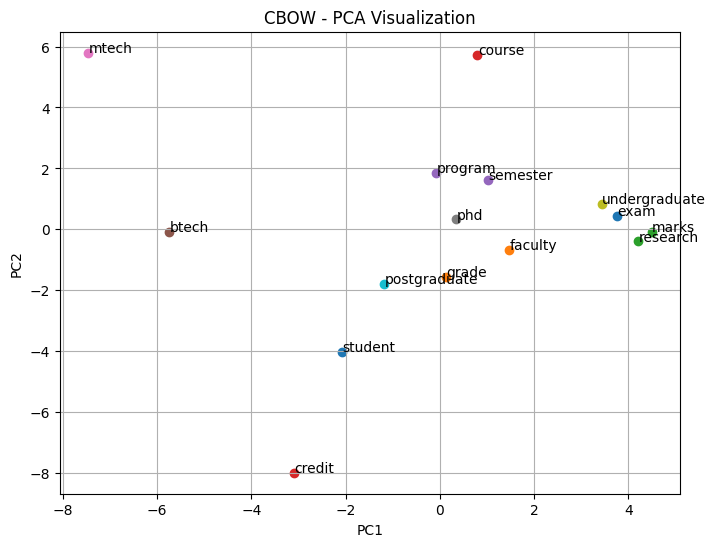

In [153]:
# CBOW
model = CBOW(vocab_size, 100)
plot_pca(model, "CBOW - PCA Visualization")

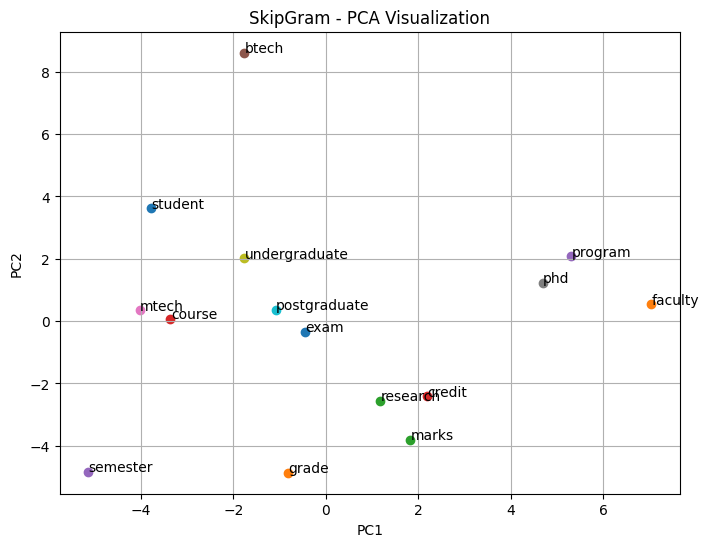

In [165]:
# Skip-gram with negative sampling
model4 = SkipGramNS(vocab_size, 100, 5)
plot_pca(model4, "SkipGram - PCA Visualization")